# May 2026 joint-training lineage reconstruction

This notebook rebuilds the disconnected W&B runs into one checkpoint
lineage, reconciles examples seen against the 28,343,296-example
training set, audits validation comparability, and fits explicitly
conditional 100-epoch projections. It reads only the bounded local W&B
export and checked-in repository artifacts.

In [1]:
import os
import sys
from pathlib import Path

os.environ["MPLCONFIGDIR"] = "/mountpoint/.exp/chess-dfm-jax/.local/cache/matplotlib"
os.environ["TMPDIR"] = "/mountpoint/.exp/chess-dfm-jax/.local/tmp"

analysis_dir = Path("/mountpoint/.exp/chess-dfm-jax/research/analysis/wandb_last_run_20260725")
repo_root = Path("/mountpoint/.exp/chess-dfm-jax")
sys.path.insert(0, str(analysis_dir))

import pandas as pd
from IPython.display import Image, Markdown, display
import analyze_lineage

results = analyze_lineage.analyze()
derived = analysis_dir / "derived"
figures = analysis_dir / "figures"

## Reconstructed exposure

“Epoch” means one training-set equivalent (28,343,296 examples), not a
W&B run or optimizer phase. Only updates inherited by the retained
checkpoint count toward its lineage; discarded branches and retries are
tracked separately.

In [2]:
summary = results["summary"]
display(Markdown(
    f"**Retained step-265k model:** {summary['retained_lineage_epochs']:.3f} "
    f"epochs / {summary['retained_lineage_examples']:,} examples.  "
    f"**W&B endpoint:** {summary['wandb_endpoint_lineage_epochs']:.3f} "
    f"epochs, but it is not the retained checkpoint."
))
lineage = pd.read_csv(derived / "lineage_segments.csv")
display(lineage[[
    "segment", "inherited_updates", "global_batch",
    "examples_in_final_lineage", "epochs_in_final_lineage",
    "optimizer_start", "jepa_sigreg_coefficient"
]])

**Retained step-265k model:** 76.063 epochs / 2,155,886,592 examples.  **W&B endpoint:** 76.687 epochs, but it is not the retained checkpoint.

,segment,inherited_updates,global_batch,examples_in_final_lineage,epochs_in_final_lineage,optimizer_start,jepa_sigreg_coefficient
0,A — fresh joint training,221432,256.0,56686592,2.000000,fresh,0.1
1,B — inherited prefix only,10000,512.0,5120000,0.180642,fresh (model-only checkpoint load),0.05
2,C1 — final run prefix,10000,512.0,5120000,0.180642,fresh (model-only checkpoint load),0.05
3,C2 — large-batch continuation to retained chec...,255000,8192.0,2088960000,73.702085,resumed within run,0.05 through step 175k; 0.01 thereafter
4,Retained final model — total,496432,NaN,2155886592,76.063369,three optimizer phases,0.1 → 0.05 → 0.01
5,W&B endpoint — not retained locally,498590,NaN,2173564928,76.687091,NaN,0.01


## Validation protocol audit

Cross-run validation is not apples-to-apples. Run C evaluated only
process 0's 96-shard slice; its first two validations used 1,024
examples, then later validations used 16,384. Projection fits therefore
use only the internally consistent run-C protocol from step 15k onward.

In [3]:
validation = pd.read_csv(derived / "validation_points.csv")
protocol_summary = (
    validation.groupby(
        ["source_run", "validation_protocol", "validation_examples",
         "validation_visible_shards"],
        dropna=False
    )
    .agg(points=("source_step", "count"),
         first_step=("source_step", "min"),
         last_step=("source_step", "max"))
    .reset_index()
)
display(protocol_summary)

,source_run,validation_protocol,validation_examples,validation_visible_shards,points,first_step,last_step
0,continuation_b512,"B: full validation pool, 32×512",16384,1524,3,5000,15000
1,final_reused_run,"C1: process-0 shard, 32×32",1024,96,2,5000,10000
2,final_reused_run,"C2: process-0 shard, 32×512",16384,96,52,15000,265000
3,initial_b256,"A: full validation pool, 32×256",8192,1524,45,5000,221432


## Validation trajectory and conditional projection

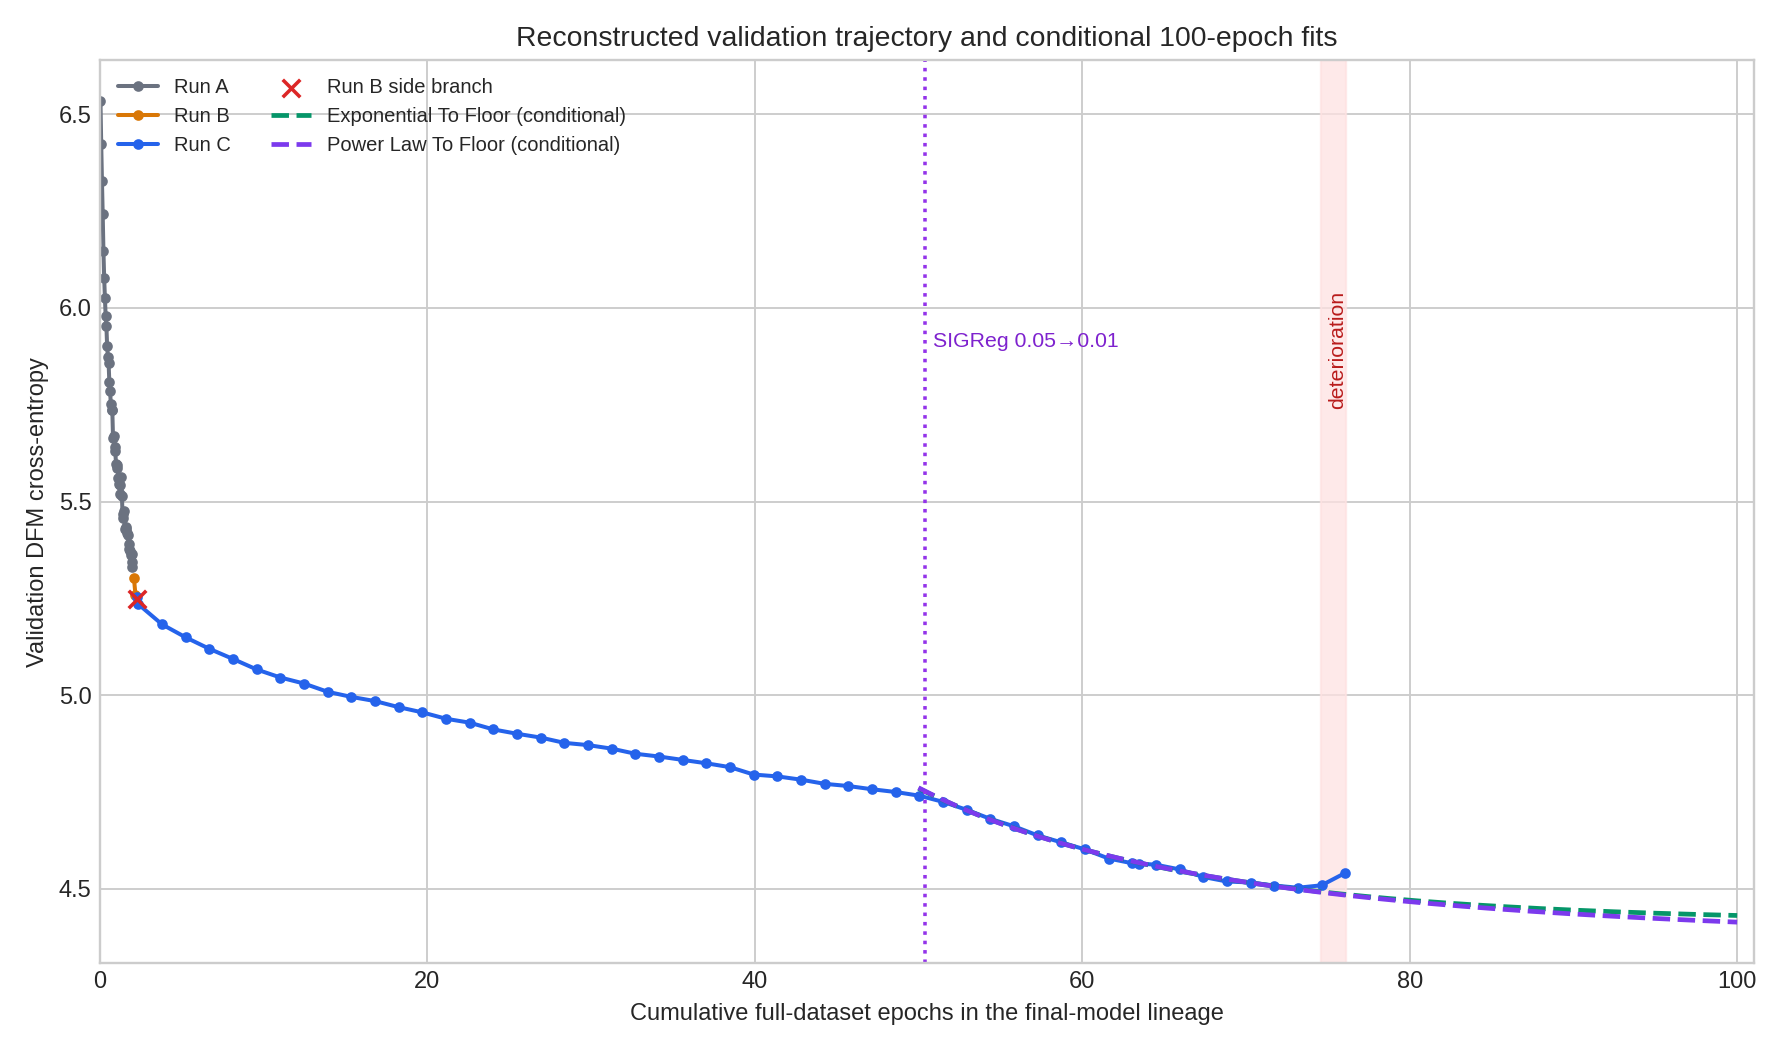

In [4]:
display(Image(filename=str(figures / "validation_lineage_projection.png")))

In [5]:
fits = pd.read_csv(derived / "projection_fits.csv")
display(fits[[
    "scenario", "model", "start_step", "cutoff_step", "fit_points",
    "rmse", "holdout_mae", "projected_val_dfm_ce_at_epoch_100"
]].sort_values(["scenario", "start_step", "model"]))

projection = summary["conditional_epoch_100_projection"]
display(Markdown(
    f"Stable-phase saturation fits give **"
    f"{projection['range_min']:.3f}–{projection['range_max']:.3f}** "
    f"at epoch 100. Tail-inclusive fits give **"
    f"{projection['tail_inclusive_range_min']:.3f}–"
    f"{projection['tail_inclusive_range_max']:.3f}**. "
    "These are scenarios, not confidence intervals."
))

,scenario,model,start_step,cutoff_step,fit_points,rmse,holdout_mae,projected_val_dfm_ce_at_epoch_100
8,holdout backtest,exponential_to_floor,180000,230000,12,0.003751,0.003937,4.421878
9,holdout backtest,power_law_to_floor,180000,230000,12,0.003861,0.005026,4.395322
0,"stable-phase, before deterioration",exponential_to_floor,180000,255000,17,0.003749,NaN,4.431372
1,"stable-phase, before deterioration",power_law_to_floor,180000,255000,17,0.003959,NaN,4.414170
2,"stable-phase, before deterioration",exponential_to_floor,200000,255000,13,0.003511,NaN,4.450661
3,"stable-phase, before deterioration",power_law_to_floor,200000,255000,13,0.003520,NaN,4.440160
4,tail-inclusive,exponential_to_floor,180000,265000,19,0.010770,NaN,4.477917
5,tail-inclusive,power_law_to_floor,180000,265000,19,0.011185,NaN,4.466449
6,tail-inclusive,exponential_to_floor,200000,265000,15,0.010424,NaN,4.499199
7,tail-inclusive,power_law_to_floor,200000,265000,15,0.011425,NaN,4.472704


Stable-phase saturation fits give **4.414–4.451** at epoch 100. Tail-inclusive fits give **4.466–4.499**. These are scenarios, not confidence intervals.

## Late-run deterioration

The best comparable validation DFM CE was at step 255k. Both DFM CE and
JEPA diagnostics then worsened; the target SIGReg spike at the endpoint
makes a literal “continue unchanged to epoch 100” extrapolation unsafe.

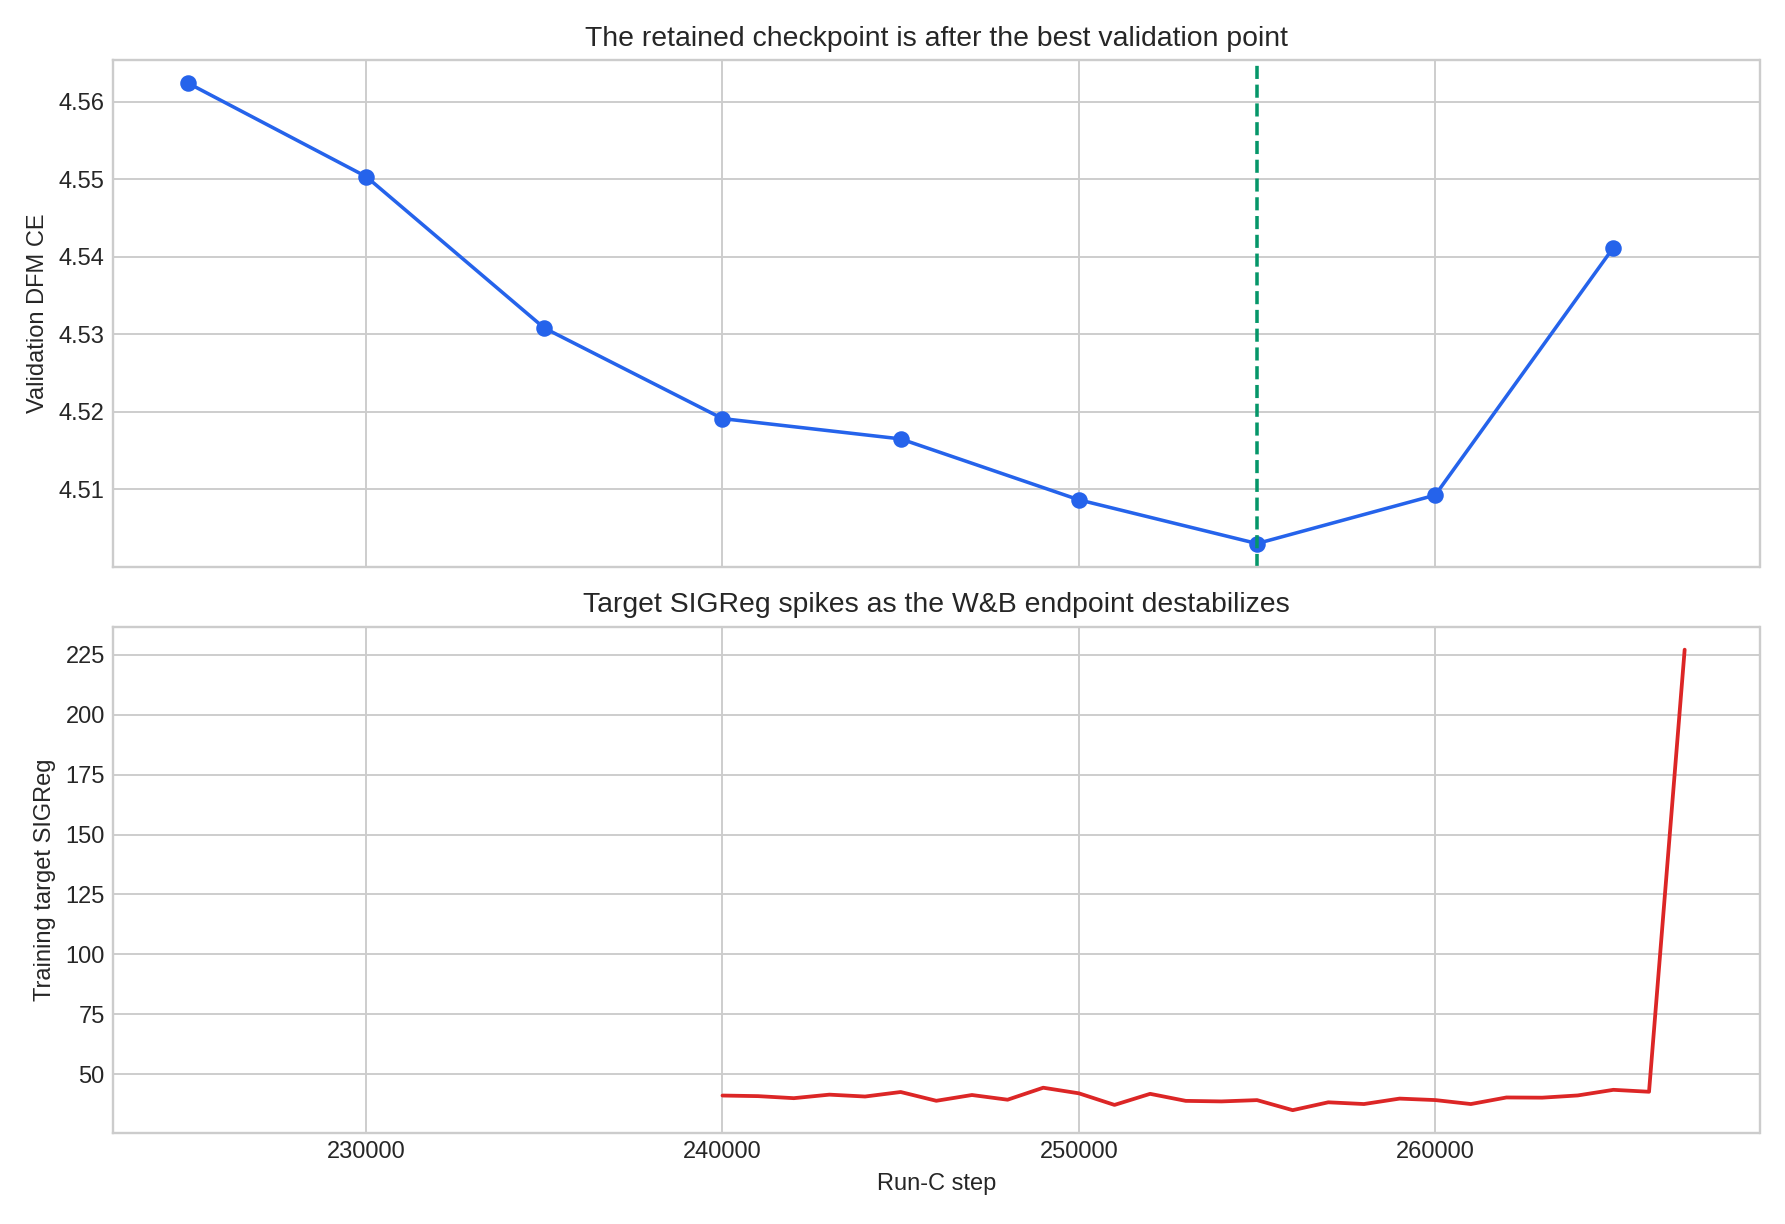

In [6]:
display(Image(filename=str(figures / "tail_instability.png")))

## Data-quality findings and clean-run implications

In [7]:
quality = results["data_quality"]
display(pd.DataFrame(quality["issues"])[
    ["severity", "confidence", "issue", "impact", "remediation"]
])
check = quality["profile"]["local_checkpoint_crosscheck"]
display(Markdown(
    f"The retained local metrics and W&B match exactly at "
    f"{len(check['common_validation_steps'])} common validation steps: "
    f"**{check['all_checked_values_exact']}**."
))

,severity,confidence,issue,impact,remediation
0,high,high,One W&B run ID was reused across batch and los...,The final config describes only the latest res...,Use one immutable run ID per recipe segment an...
1,high,high,Validation population changed with process top...,A/B evaluated the full validation pool; C eval...,Create a topology-invariant frozen validation ...
2,high,confirmed,Checkpoint rollback caused duplicate training ...,"At the step-175k restart, retrained steps were...",Log monotonic optimizer_updates_total and exam...
3,medium,high,The displayed composite loss is not longitudin...,Teacher forcing and JEPA SIGReg weights change...,Version the objective and log raw components p...
4,medium,high,The retained checkpoint is not the W&B endpoint.,"W&B reached step 267,158, while the locally ev...",Log checkpoint artifact IDs and mark the canon...


The retained local metrics and W&B match exactly at 9 common validation steps: **True**.

## Bottom line

The final retained model is a roughly 76-epoch model assembled across
three optimizer phases, not an eight-epoch run. Its best observed
comparable DFM CE was 4.503 at about 73.17 epochs; the retained step-265k
checkpoint had worsened to 4.541. A clean run should make validation
topology-invariant, version the objective, log monotonic examples seen
and optimizer updates, and bind every evaluation to an explicit
checkpoint artifact before attempting to calibrate loss against Elo.